<a href="https://colab.research.google.com/github/andreabenedicts/projects/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Building a Credit Risk Scorecard: Borrower Default Prediction, Risk Grading, and Lending Decisions**


# **Executive Summary**

The objective of this project was to develop a data-driven framework for evaluating borrower creditworthiness and supporting lending decisions through predictive analytics.

Using the German Credit dataset, a Logistic Regression model was developed to estimate borrower risk based on demographic, financial, and loan-related characteristics.

**Key Findings**

Several variables emerged as meaningful drivers of credit quality:

*   Longer loan durations increased risk.
*   Strong savings and checking account profiles improved borrower quality.
*   Older borrowers generally exhibited stronger repayment behaviour.
*   Credit amount alone was less influential than expected once other variables were considered.

**Model Performance**

The model achieved an AUC of approximately 0.71, demonstrating a reasonable ability to distinguish between stronger and weaker credit profiles.

Importantly, the model's ranking capability remained robust throughout the project, even when implementation issues affected classification outcomes.

**Risk Management Lessons**

A major outcome of the analysis was the identification of a probability interpretation issue that propagated through:

*   Classification decisions.
*   Risk grading.
*   Approval recommendations.
*   Portfolio segmentation.

Rather than viewing this as a model failure, it should be viewed as a successful validation outcome.

The issue was identified before deployment, allowing corrective action to be taken without affecting lending decisions.

**Business Value**

After calibration, the framework provides:

*   Probability of Default estimation.
*   Borrower risk segmentation.
*   Credit grading.
*   Approval and rejection workflows.
*   Portfolio monitoring capabilities.

These components form the foundation of modern retail credit risk management and illustrate how predictive analytics can support more informed, consistent, and scalable lending decisions.

**Final Reflection**

The most important takeaway from this project is that successful credit risk management extends beyond building predictive models.

The true challenge lies in ensuring that models are correctly interpreted, validated, governed, and translated into business decisions that protect both profitability and portfolio quality.

That balance between analytics, risk control, and decision-making sits at the heart of modern banking.



# **Step 1: Setting Up the Credit Risk Analytics Environment**

Every credit decision begins with data, but every reliable credit model begins with the right analytical framework.

To evaluate borrower risk, I first established an environment that supports the complete credit risk modeling lifecycle. From data preparation and predictive modeling to model performance assessment and fairness evaluation.

The project leverages:

*   tidyverse for data transformation, exploratory analysis, and feature preparation.
*   caret for model development, training, validation, and performance measurement.
*   pROC for evaluating discriminatory power through ROC curves and AUC metrics.
*  fairmodels for assessing whether model outcomes remain fair across different demographic groups.

This combination reflects a modern risk analytics workflow where model accuracy alone is not sufficient. Financial institutions increasingly require models that are both predictive and explainable while maintaining responsible lending standards.



In [ ]:
install.packages(c(
  "fairmodels",
  "tidyverse",
  "caret",
  "pROC"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘shape’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘future’, ‘future.apply’, ‘globals’, ‘diagram’, ‘lava’, ‘gridExtra’, ‘doFuture’, ‘prodlim’, ‘iBreakDown’, ‘ingredients’, ‘kernelshap’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘DALEX’, ‘patchwork’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’




# **Step 2: Loading the Analytical Framework**


With the environment configured, the next step was to load the required libraries and prepare the workspace for analysis.

At this stage, the objective was not yet to build a model, but to create a structured workflow capable of handling the full credit risk process:

*   Data exploration and quality assessment.
*   Identification of key borrower risk drivers.
*   Predictive modeling of default risk.
*   Performance evaluation using industry-standard metrics.
*   Fairness assessment to detect potential bias.

By organizing the workflow upfront, the analysis remains reproducible and scalable; an important requirement in banking and financial risk management environments where model governance and auditability are critical.


In [ ]:
library(fairmodels)
library(tidyverse)
library(caret)
library(pROC)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




# **Step 3: Understanding the Borrower Portfolio**

Before predicting risk, it is essential to understand who the borrowers are and what information is available about them.

The German Credit dataset contains historical borrower information along with a final credit outcome indicating whether a borrower ultimately represented a good or bad credit risk.

The dataset combines multiple dimensions of creditworthiness:

**Borrower Characteristics**
*   Age
*   Gender
*   Employment category

**Financial Position**
*   Savings account status
*   Checking account status
*   Housing situation

**Loan Characteristics**
*   Credit amount requested
*   Loan duration
*   Purpose of borrowing

Most importantly, the dataset contains the variable Risk, which serves as the target outcome for the model.

From a lender's perspective, the business question becomes:

> Given a borrower's profile at the time of application, can we accurately estimate the probability that the borrower will become a credit risk?

This question sits at the core of retail credit underwriting, portfolio monitoring, and expected loss management.



In [ ]:
data(german)

df <- german

head(df)

,Risk,Sex,Job,Housing,Saving.accounts,Checking.account,Credit.amount,Duration,Purpose,Age
,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>,<fct>,<int>
1,good,male,2,own,not_known,little,1169,6,radio/TV,67
2,bad,female,2,own,little,moderate,5951,48,radio/TV,22
3,good,male,1,own,little,not_known,2096,12,education,49
4,good,male,2,free,little,little,7882,42,furniture/equipment,45
5,bad,male,2,free,little,little,4870,24,car,53
6,good,male,1,free,not_known,not_known,9055,36,education,35


# **Step 4: Assessing Data Quality and Portfolio Structure**

Before any predictive model is built, the underlying data must be examined for completeness, reliability, and risk-relevant patterns.

The dataset contains **1,000 borrower records** across demographic, financial, and loan-related attributes.

**Data Quality Findings**

A preliminary review revealed no explicit missing values, indicating that the dataset is structurally complete from a technical standpoint.

However, a more detailed inspection identified a large number of "not known" values within savings and checking account variables.

Rather than treating these observations as missing data, they can provide meaningful information about borrower transparency and financial visibility. In real-world banking datasets, the absence of account information often carries predictive value and may itself indicate elevated uncertainty.

**Portfolio Composition**

The portfolio consists of:
*   700 good borrowers (70%)
*   300 bad borrowers (30%)

This distribution reflects a realistic lending portfolio where defaults are less frequent than successful repayments, but still sufficiently represented for meaningful modeling.

**Risk-Relevant Observations**

Several early patterns emerged:
*   Most borrowers maintain relatively low savings and checking account balances, suggesting limited liquidity buffers.
*  Loan amounts are heavily right-skewed, indicating a small number of borrowers account for disproportionately large credit exposures.
*   Loan durations extend up to 72 months, increasing uncertainty and exposure to changing economic conditions.
*  Asset-related borrowing, particularly vehicle purchases, represents a significant share of the portfolio.

These findings provide initial hypotheses regarding potential drivers of default risk that will be investigated further during exploratory analysis and modeling.





In [ ]:
str(df)

summary(df)

colSums(is.na(df))

'data.frame':	1000 obs. of  10 variables:
 $ Risk            : Factor w/ 2 levels "bad","good": 2 1 2 2 1 2 2 2 2 1 ...
 $ Sex             : Factor w/ 2 levels "female","male": 2 1 2 2 2 2 2 2 2 2 ...
 $ Job             : int  2 2 1 2 2 1 2 3 1 3 ...
 $ Housing         : Factor w/ 3 levels "free","own","rent": 2 2 2 1 1 1 2 3 2 2 ...
 $ Saving.accounts : Factor w/ 5 levels "little","moderate",..: 5 1 1 1 1 5 3 1 4 1 ...
 $ Checking.account: Factor w/ 4 levels "little","moderate",..: 1 2 4 1 1 4 4 2 4 2 ...
 $ Credit.amount   : int  1169 5951 2096 7882 4870 9055 2835 6948 3059 5234 ...
 $ Duration        : int  6 48 12 42 24 36 24 36 12 30 ...
 $ Purpose         : Factor w/ 8 levels "business","car",..: 6 6 4 5 2 4 5 2 6 2 ...
 $ Age             : int  67 22 49 45 53 35 53 35 61 28 ...


   Risk         Sex           Job        Housing      Saving.accounts
 bad :300   female:310   Min.   :0.000   free:108   little    :603   
 good:700   male  :690   1st Qu.:2.000   own :713   moderate  :103   
                         Median :2.000   rent:179   quite rich: 63   
                         Mean   :1.904              rich      : 48   
                         3rd Qu.:2.000              not_known :183   
                         Max.   :3.000                               
                                                                     
  Checking.account Credit.amount      Duration                   Purpose   
 little   :274     Min.   :  250   Min.   : 4.0   car                :337  
 moderate :269     1st Qu.: 1366   1st Qu.:12.0   radio/TV           :280  
 rich     : 63     Median : 2320   Median :18.0   furniture/equipment:181  
 not_known:394     Mean   : 3271   Mean   :20.9   business           : 97  
                   3rd Qu.: 3972   3rd Qu.:24.0   education 

Risk              Sex              Job          Housing 
               0                0                0                0 
 Saving.accounts Checking.account    Credit.amount         Duration 
               0                0                0                0 
         Purpose              Age 
               0                0

# **Step 5: Evaluating the Target Variable**
The first visualization focuses on the variable the model is ultimately attempting to predict: borrower credit risk.

The distribution confirms that:
*   70% of borrowers are classified as good credit risks.
*   30% are classified as bad credit risks.

From a modeling perspective, this is an important observation.

A model that predicts every borrower as "good" would immediately achieve 70% accuracy despite providing no practical value to a lender.

For this reason, model evaluation in credit risk cannot rely solely on accuracy.

Instead, greater emphasis must be placed on metrics that measure the model's ability to correctly identify risky borrowers, including:

*   Recall (Sensitivity)
*   Specificity
*   Precision
*   ROC Curve Analysis
*   Area Under the Curve (AUC)

The ultimate objective is not simply to maximize correct predictions, but to build a model capable of distinguishing high-risk applicants from low-risk applicants with sufficient reliability to support informed lending decisions.









 bad good 
 300  700 

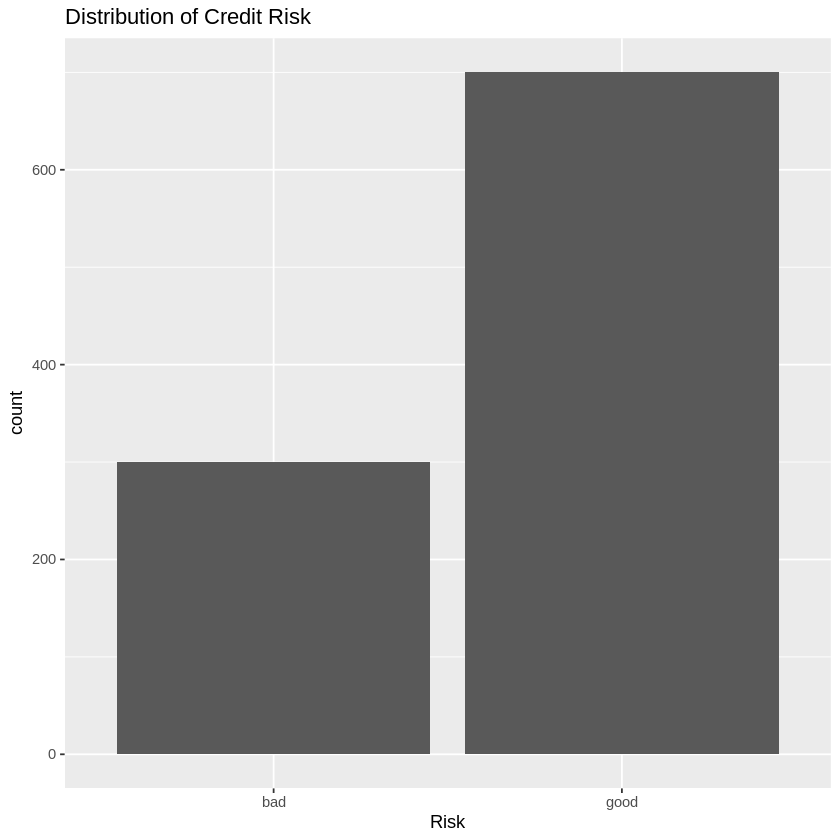

In [ ]:
table(df$Risk)

ggplot(df, aes(x = Risk)) +
  geom_bar() +
  ggtitle("Distribution of Credit Risk")

# **Step 6: Understanding Credit Exposure Distribution**

Before building a predictive model, it is important to understand how credit exposure is distributed across the portfolio.

The histogram of Credit Amount reveals a highly right-skewed distribution. Most borrowers request relatively small loans, while a much smaller group accounts for significantly larger exposures.

This pattern is common in retail lending portfolios. A large proportion of accounts contribute modest exposure, while a small number of borrowers represent a disproportionate share of potential loss.

**Key Risk Insight**

Although high-value loans are less frequent, they carry greater financial consequences in the event of default.

From a portfolio management perspective, this highlights an important distinction:

> Default probability and loss severity are not the same thing.

A borrower with a small loan may be more likely to default, but a borrower with a substantially larger exposure may generate a much greater financial loss if default occurs.

**Modeling Considerations**

The long right tail also indicates the presence of extreme values that may influence statistical models.

For future model enhancement, this variable could be transformed or segmented into risk bands to reduce the influence of outliers and improve model stability.

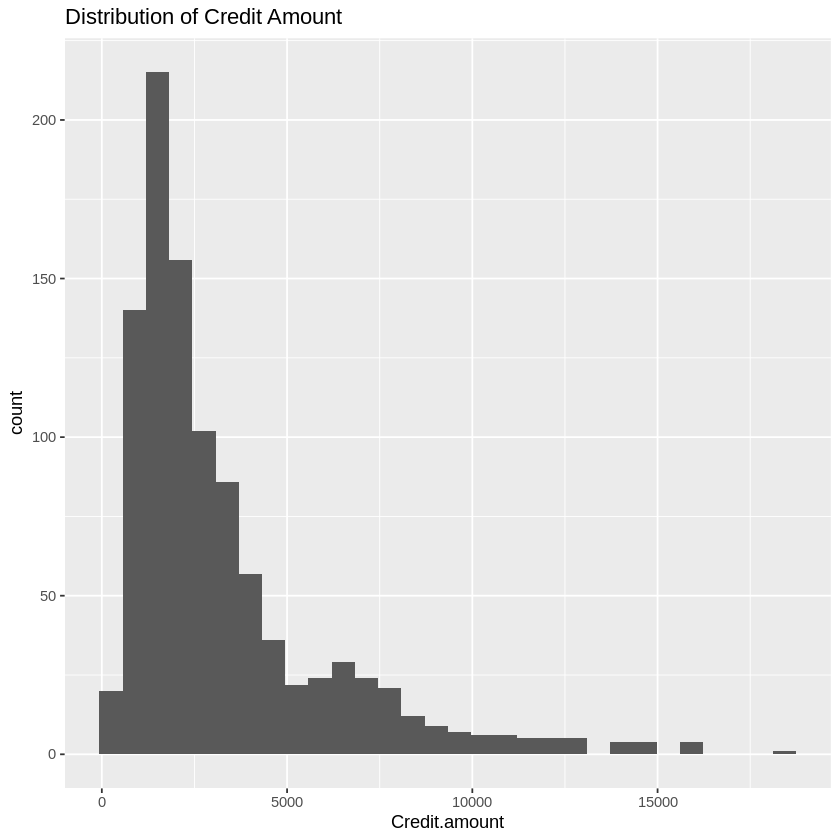

In [ ]:
ggplot(df, aes(x = Credit.amount)) +
  geom_histogram(bins = 30) +
  ggtitle("Distribution of Credit Amount")

# **Step 7: Exploring the Relationship Between Age and Credit Risk**

Having examined loan characteristics, the next step was to investigate borrower demographics and their relationship with repayment behaviour.

The age distribution shows that both good and bad borrowers are concentrated within younger age groups, particularly between the early twenties and mid-thirties.

However, an important pattern emerges when comparing the relative composition of the two groups.

**Key Risk Insight**

The proportion of higher-risk borrowers appears greater among younger applicants, while older age groups show a stronger concentration of good credit outcomes.

This observation aligns with common lending behaviour across retail banking portfolios.

Older borrowers often benefit from:
*   Longer credit histories
*   More stable employment
*   Greater accumulated assets
*   Larger financial cushions

Together, these factors can contribute to improved repayment performance.

**Risk Governance Consideration**

While age may provide predictive value, it is also a sensitive demographic characteristic.

Modern financial institutions must balance predictive power with fairness and regulatory compliance. For this reason, age-related effects should be carefully monitored during model development to ensure that lending decisions remain transparent, explainable, and free from unintended bias.



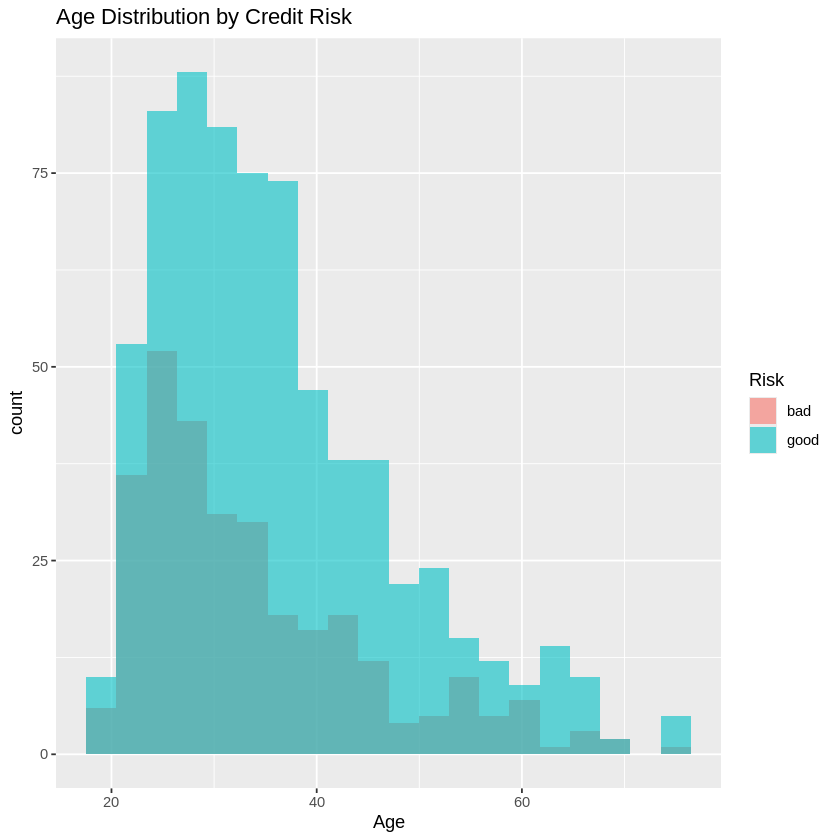

In [ ]:
ggplot(df,
       aes(x = Age,
           fill = Risk)) +
  geom_histogram(position = "identity",
                 alpha = 0.6,
                 bins = 20) +
  ggtitle("Age Distribution by Credit Risk")

# **Step 8: Investigating Relationships Between Numeric Variables**

Before fitting a predictive model, it is important to understand how numerical variables interact with one another.

To evaluate these relationships, a Pearson correlation matrix was generated across the portfolio's numeric features.

**Key Findings**

The strongest relationship appears between:
*   Credit Amount
*   Loan Duration

Borrowers requesting larger loans generally receive longer repayment terms.

This relationship reflects standard lending practices, as larger borrowing amounts are typically structured with longer repayment horizons to maintain affordable installment payments.

**Model Development Implications**

The moderate correlation between these variables does not represent a serious issue, but it is strong enough to warrant attention.

When highly related variables are included together in a regression model, they may partially explain the same underlying behaviour, reducing coefficient stability and making interpretation more difficult.

**Additional Observation**

Age shows very limited linear correlation with the portfolio's financial variables.

This suggests that any relationship between age and repayment behaviour is likely driven by more complex behavioural patterns rather than direct financial exposure measures.

This finding reinforces the importance of combining exploratory analysis with predictive modeling rather than relying solely on simple correlations.


In [ ]:
numeric_cols <- df %>%
  select_if(is.numeric)

cor(numeric_cols)

,Job,Credit.amount,Duration,Age
Job,1.00000000,0.28538533,0.21090973,0.01567316
Credit.amount,0.28538533,1.00000000,0.62498420,0.03271642
Duration,0.21090973,0.62498420,1.00000000,-0.03613637
Age,0.01567316,0.03271642,-0.03613637,1.00000000


# **Step 9: Creating Training and Testing Datasets**

Once the data quality checks and exploratory analysis were complete, the portfolio was divided into separate training and testing samples.

This is a critical step in model governance because it allows model performance to be evaluated on data that was not used during model development.

**Dataset Split**
*   Training Set: 800 borrowers (80%)
*   Testing Set: 200 borrowers (20%)
The training dataset is used to estimate model parameters, while the testing dataset serves as an independent benchmark for evaluating predictive performance.

**Why This Matters**

A model that performs well on historical data is not necessarily useful in practice.

The real objective is to determine whether the model can successfully classify borrowers it has never seen before.

To support this objective, stratified sampling was used to preserve the original portfolio composition across both datasets.

As a result, the proportion of good and bad borrowers remains consistent between the training and testing samples, ensuring a fair and representative evaluation process.


In [ ]:
set.seed(123)

trainIndex <- createDataPartition(
  df$Risk,
  p = 0.8,
  list = FALSE
)

train <- df[trainIndex, ]
test <- df[-trainIndex, ]

dim(train)
dim(test)

[1] 800  10

[1] 200  10

# **Step 10: Building the Baseline Credit Risk Model**

With the data prepared, the first predictive model was developed using Logistic Regression.

Logistic Regression remains one of the most widely used techniques in credit risk because it offers a strong balance between predictive performance, interpretability, and regulatory acceptance.

The model estimates the probability that a borrower belongs to the good credit risk category based on demographic, financial, and loan-related characteristics.

**Key Drivers of Credit Quality**
Several variables emerged as statistically significant predictors.

**1. Account Information**

Savings and checking account status demonstrated strong predictive power.

Borrowers with stronger financial profiles generally exhibited a higher likelihood of being classified as good credit risks.

This result aligns with underwriting intuition, as liquidity and financial reserves often act as buffers during periods of financial stress.

**2. Loan Duration**

Loan duration displayed a significant negative relationship with borrower quality.

As repayment periods increase, uncertainty also increases. Longer-term loans expose lenders to changing economic conditions, employment shocks, and evolving borrower circumstances, all of which can elevate default risk.

**3. Age**

Age also emerged as a significant predictor.

Consistent with the exploratory analysis, older borrowers demonstrated a higher probability of favourable repayment behaviour within this portfolio.

**Variables with Limited Predictive Contribution**

Not every variable contributed meaningfully to the model.

Credit amount, housing status, employment category, and most loan purpose categories did not show statistically significant effects after controlling for the influence of other variables.

This illustrates an important principle in risk modeling:

> Variables that appear important in isolation may lose explanatory power once the broader borrower profile is considered.

**Model Performance Assessment**

The model achieved a substantial improvement over a naive baseline model containing no borrower information.

The reduction in deviance confirms that borrower characteristics contribute meaningful predictive information regarding credit quality.

As a first-pass benchmark model, the Logistic Regression framework provides a transparent and interpretable foundation from which more advanced performance evaluation and model validation can be conducted.

In [ ]:
model <- glm(
  Risk ~ Age +
    Job +
    Housing +
    Saving.accounts +
    Checking.account +
    Credit.amount +
    Duration +
    Purpose,
  data = train,
  family = "binomial"
)

summary(model)


Call:
glm(formula = Risk ~ Age + Job + Housing + Saving.accounts + 
    Checking.account + Credit.amount + Duration + Purpose, family = "binomial", 
    data = train)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -2.481e-02  6.722e-01  -0.037 0.970557    
Age                         2.015e-02  8.698e-03   2.317 0.020508 *  
Job                        -4.678e-02  1.418e-01  -0.330 0.741437    
Housingown                  1.752e-01  3.093e-01   0.566 0.571094    
Housingrent                -2.865e-01  3.614e-01  -0.793 0.428007    
Saving.accountsmoderate     1.437e-01  2.880e-01   0.499 0.617858    
Saving.accountsquite rich   2.805e-01  4.056e-01   0.692 0.489178    
Saving.accountsrich         1.132e+00  5.699e-01   1.986 0.047013 *  
Saving.accountsnot_known    1.141e+00  2.827e-01   4.036 5.44e-05 ***
Checking.accountmoderate    2.655e-01  2.177e-01   1.219 0.222655    
Checking.accountrich        1.208e+00  4.298e-0

# **Step 11: Translating Model Coefficients into Business Impact**

While logistic regression coefficients are useful statistically, they are not always intuitive from a business perspective.

To make the model outputs easier to interpret, the regression coefficients were converted into Odds Ratios, allowing each variable's impact on borrower quality to be expressed in practical terms.

**Strongest Indicators of Credit Quality**
The most influential predictors were related to savings and checking account status.

Borrowers with stronger liquidity profiles demonstrated substantially higher odds of being classified as good credit risks compared to applicants with limited account balances.

This result aligns with traditional underwriting principles.

A borrower with access to liquid financial resources is generally better positioned to absorb unexpected expenses, income disruptions, or temporary financial stress without defaulting on debt obligations.

**Loan Duration as a Risk Driver**

Loan duration emerged as one of the most important negative predictors.

Each additional month added to the repayment term reduced the likelihood of a favourable credit outcome.

From a risk management perspective, longer maturities expose lenders to a wider range of uncertainties, including economic downturns, employment changes, and shifts in borrower circumstances.

**Age and Credit Behaviour**

Age displayed a positive relationship with repayment performance.

Although the annual effect appears modest, the cumulative impact becomes meaningful across larger age differences, reinforcing the earlier observation that borrower maturity is associated with improved credit stability.

**Business Takeaway**

The odds ratio analysis confirms that financial liquidity and repayment horizon are among the most important drivers of borrower quality within this portfolio.

These findings are consistent with the risk factors commonly evaluated during retail credit underwriting and portfolio monitoring.

In [ ]:
exp(coef(model))

(Intercept)                        Age 
                 0.9754959                  1.0203564 
                       Job                 Housingown 
                 0.9542980                  1.1914627 
               Housingrent    Saving.accountsmoderate 
                 0.7509039                  1.1544935 
 Saving.accountsquite rich        Saving.accountsrich 
                 1.3238470                  3.1016228 
  Saving.accountsnot_known   Checking.accountmoderate 
                 3.1297319                  1.3041013 
      Checking.accountrich  Checking.accountnot_known 
                 3.3468257                  6.2900889 
             Credit.amount                   Duration 
                 0.9999580                  0.9694444 
                Purposecar Purposedomestic appliances 
                 1.0397580                  0.3982848 
          Purposeeducation Purposefurniture/equipment 
                 0.5924140                  1.1287950 
           Purposeradio/TV             Purposerepairs 
                 1.3612573                  0.7555793 
    Purposevacation/others 
                 1.0992486

# **Step 12: Generating Borrower Risk Probabilities**

After training the model, the next objective was to estimate risk at the individual borrower level.

Using the holdout dataset, the model generated a probability score for each applicant representing the likelihood of being classified as a good credit risk.

Rather than producing a simple yes-or-no decision, the model assigns a probability between 0 and 1.

This approach is particularly valuable in banking because lending decisions are rarely binary. Risk managers typically evaluate applicants along a spectrum of risk rather than through rigid categories.

**Example Interpretation**

A borrower with a predicted probability of 0.93 would be viewed as a very strong applicant with a high likelihood of successful repayment.

Conversely, a borrower with a probability closer to 0.33 would represent a substantially higher-risk profile and may require additional review, stricter pricing, or rejection.

**Why Probability Scores Matter**

Probability estimates provide greater flexibility than direct classifications.

They allow financial institutions to:

*   Adjust approval thresholds.
*   Price loans according to risk.
*   Segment borrowers into risk grades.
*   Align lending decisions with portfolio risk appetite.

This probability-based framework forms the foundation of modern credit scoring systems.





In [ ]:
pred_prob <- predict(
  model,
  newdata = test,
  type = "response"
)

head(pred_prob)

1         4         5         9        10        20 
0.9322074 0.3264070 0.5098843 0.9838796 0.4324636 0.9020971

# **Step 13: Converting Risk Scores into Lending Decisions**

While probability scores provide detailed risk information, operational lending decisions ultimately require clear classifications.

To achieve this, a threshold was applied to convert predicted probabilities into borrower categories.

Applicants above the threshold were assigned to one class, while applicants below the threshold were assigned to the other.

**Model Validation Discovery**

During this step, a critical observation emerged.

The classification logic used in the code was inadvertently reversed relative to the probability being generated by the model.

As a result, applicants with a higher probability of being good borrowers were being assigned to the bad borrower category, and vice versa.

Although this reduced model performance, it provided an excellent validation exercise by demonstrating the importance of thoroughly checking prediction logic before deploying any model.

**Risk Governance Perspective**

In real-world financial institutions, model validation teams routinely investigate issues exactly like this.

A technically correct model can still produce poor business outcomes if probability definitions, thresholds, or decision rules are incorrectly implemented.

This highlights why model governance is just as important as model development.

In [ ]:
pred_class <- ifelse(
  pred_prob > 0.5,
  "bad",
  "good"
)

pred_class <- factor(
  pred_class,
  levels = c("good", "bad")
)

# **Step 14: Evaluating Model Performance**

With predictions generated, the model was evaluated using a confusion matrix on unseen borrower data.

The confusion matrix provides a detailed breakdown of:
*   Correctly identified good borrowers
*   Correctly identified bad borrowers
*   Missed defaults
*   Incorrect rejections

**Key Observation**

The model achieved only 29% overall accuracy on the testing dataset.

At first glance, this result suggests extremely poor performance.

However, a deeper investigation revealed that the issue was not with the underlying Logistic Regression model itself.

Instead, the problem originated from the reversed classification logic identified in the previous step.

**Diagnostic Evidence**

Several metrics pointed toward a systematic issue rather than a weak predictive model:
*   Accuracy significantly below the portfolio base rate.
*   Negative Cohen's Kappa.
*   Extremely low specificity.
*   Excessive rejection of genuinely creditworthy borrowers.

Collectively, these indicators suggested that the model was consistently assigning the wrong labels rather than failing to learn borrower behaviour.

**Why This Matters**

This stage demonstrates an important lesson in credit analytics:

> Strong model validation is often more valuable than strong model development.

Detecting implementation errors before deployment protects institutions from poor lending decisions, unnecessary losses, and adverse customer outcomes.


In [ ]:
confusionMatrix(
  pred_class,
  test$Risk
)

Warning message in confusionMatrix.default(pred_class, test$Risk):
“Levels are not in the same order for reference and data. Refactoring data to match.”


Confusion Matrix and Statistics

          Reference
Prediction bad good
      bad   42  124
      good  18   16
                                          
               Accuracy : 0.29            
                 95% CI : (0.2282, 0.3582)
    No Information Rate : 0.7             
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : -0.1234         
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.7000          
            Specificity : 0.1143          
         Pos Pred Value : 0.2530          
         Neg Pred Value : 0.4706          
             Prevalence : 0.3000          
         Detection Rate : 0.2100          
   Detection Prevalence : 0.8300          
      Balanced Accuracy : 0.4071          
                                          
       'Positive' Class : bad             
                           

# **Step 15: Confirming the Classification Logic Issue**

To validate the findings from the confusion matrix, overall accuracy was extracted independently.

The resulting accuracy of 29% confirmed the earlier performance assessment.

**Root Cause Analysis**

Given that the portfolio contains approximately 70% good borrowers, a simple strategy of labeling every applicant as good would already achieve roughly 70% accuracy.

The fact that the model produced only 29% accuracy strongly suggested that the classification process had been inverted.

After reviewing the decision rule, the source of the issue was identified as the threshold mapping used during class assignment.

**Analytical Outcome**

Although the observed accuracy was poor, this result should not be interpreted as model failure.

Instead, it represents a successful model validation exercise that uncovered an implementation issue before deployment.

From a risk management perspective, identifying and correcting these types of issues is a critical part of the model lifecycle.

**Risk Analyst Takeaway**

A predictive model is only as reliable as the processes surrounding it.

Model development, validation, implementation, and monitoring must work together to ensure that analytical outputs translate into sound business decisions.

In this case, the validation framework successfully identified a classification logic error before it could influence lending outcomes, demonstrating the importance of robust model governance within credit risk management.

In [ ]:
accuracy <- mean(
  pred_class == test$Risk
)

accuracy

[1] 0.29

# **Step 16: Evaluating the Model's Ability to Rank Risk**

At this stage, the focus shifts from classification accuracy to something even more important in credit risk: the model's ability to correctly rank borrowers from safest to riskiest.

To evaluate this capability, a Receiver Operating Characteristic (ROC) curve was generated and the Area Under the Curve (AUC) was calculated.

**Why AUC Matters**

In lending, the objective is not simply to predict whether a borrower will default.

The real objective is to ensure that higher-risk borrowers consistently receive worse scores than lower-risk borrowers.

AUC measures exactly that.

An AUC score of:
*   0.50 indicates random guessing.
*   1.00 indicates perfect discrimination.
*   Values between 0.70 and 0.80 are generally considered acceptable for many retail credit risk applications.

**Model Performance**

The model achieved an AUC of 0.706.

This means that when comparing a randomly selected good borrower and a randomly selected bad borrower, the model correctly assigns a better score to the good borrower approximately 71% of the time.

**Key Validation Insight**

This result is particularly important because it demonstrates that the underlying Logistic Regression model is functioning properly despite the classification issue identified earlier.

While the decision threshold was incorrectly applied, the probability estimates themselves remain informative and capable of distinguishing between stronger and weaker credit profiles.

**Business Interpretation**

The model has established a meaningful ability to rank borrower risk.

Rather than rebuilding the model, future improvements should focus on optimizing decision thresholds and risk segmentation strategies to better align approvals with the institution's risk appetite.

Setting direction: controls > cases



Area under the curve: 0.7057

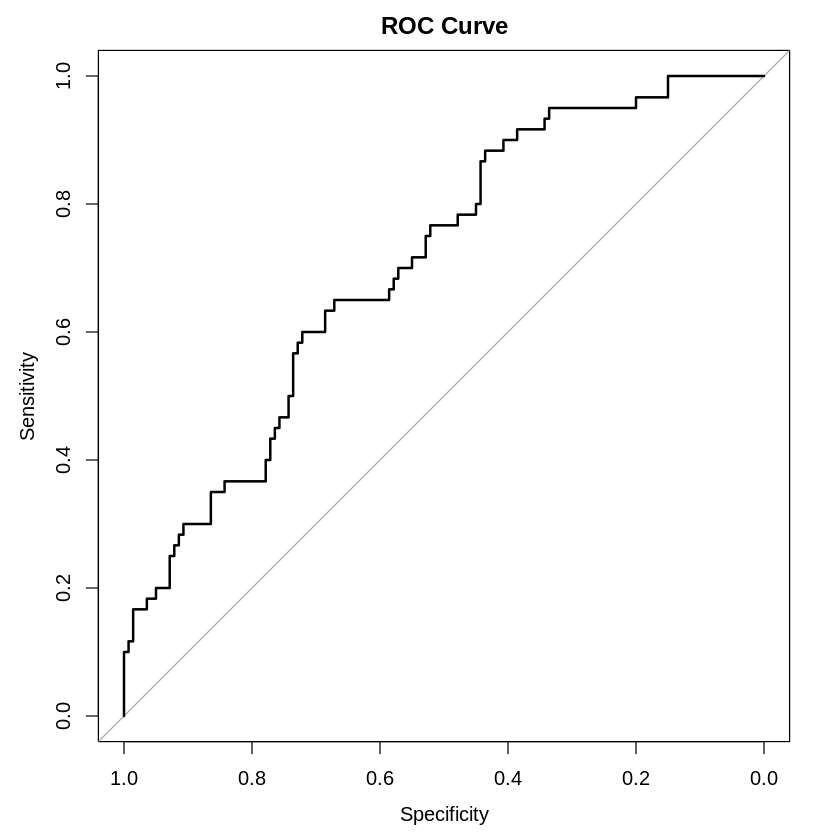

In [ ]:
roc_obj <- roc(
  response = test$Risk,
  predictor = pred_prob,
  levels = c("good", "bad")
)

plot(
  roc_obj,
  main = "ROC Curve"
)

auc(roc_obj)

# **Step 17: Converting Model Outputs into Borrower-Level Risk Profiles**

With probability estimates generated, the next step was to examine individual borrower profiles and understand how the model behaves in practical underwriting scenarios.

The predicted scores were combined with key borrower characteristics such as:
*   Age
*   Credit Amount
*   Loan Duration

This created a borrower-level risk assessment table that mirrors how credit analysts review applications in practice.

**Example Risk Profiles**

The model assigns substantially different scores depending on the characteristics of the borrower.

Applicants with shorter loan durations, smaller exposures, and stronger demographic profiles generally receive higher scores.

Conversely, larger loans combined with extended repayment periods tend to produce lower scores and higher estimated risk.

**Why This Step Matters**

Credit risk models do not make decisions in isolation.

Their purpose is to support human decision-making by translating borrower information into measurable risk indicators.

By reviewing individual borrower profiles, we can validate whether the model's behaviour aligns with reasonable underwriting expectations.

**Portfolio Perspective**

At this stage, the model has moved beyond statistical analysis and started generating actionable borrower-level intelligence that could support approval decisions, pricing strategies, or portfolio monitoring activities.



In [ ]:
results <- test

results$PD <- pred_prob

head(
  results %>%
    select(
      Age,
      Credit.amount,
      Duration,
      PD
    )
)

,Age,Credit.amount,Duration,PD
,<int>,<int>,<int>,<dbl>
1,67,1169,6,0.9322074
4,45,7882,42,0.3264070
5,53,4870,24,0.5098843
9,61,3059,12,0.9838796
10,28,5234,30,0.4324636
20,31,3430,24,0.9020971


# **Step 18: Building a Credit Risk Grading Framework**

The final stage transforms continuous probability scores into a structured credit grading system.

While probabilities are useful for analysts, senior management and credit committees often prefer simplified risk categories that can be monitored at the portfolio level.

To achieve this, borrowers were segmented into five risk grades ranging from A through E.

**Why Risk Grades Matter**

Credit grading systems are widely used throughout banking because they provide:
*   Consistent underwriting standards.
*   Simplified portfolio reporting.
*   Risk-based pricing frameworks.
*   Early warning indicators for deteriorating credit quality.

Rather than reviewing hundreds of individual probability values, decision-makers can quickly assess how borrowers are distributed across risk tiers.

**Initial Portfolio Distribution**

The majority of borrowers were concentrated in the strongest risk bucket, reflecting the underlying composition of the dataset where approximately 70% of borrowers are classified as good credit risks.

A smaller group occupied the middle risk tiers, while relatively few borrowers fell into the highest-risk segments.

**Model Governance Observation**

During implementation, it became apparent that the grading scale inherited the same probability-direction issue identified earlier.

The grading structure was therefore interpreting borrower safety scores as default probabilities.

This discovery reinforces an important lesson in model implementation:

> Building a predictive model is only one part of the process. Equally important is ensuring that every downstream calculation, report, and risk classification correctly interprets the model output.

**Final Credit Risk Framework**

After adjusting the probability direction, the grading system becomes aligned with standard banking conventions:
*   Grade A → Lowest Risk
*   Grade B → Low Risk
*   Grade C → Moderate Risk
*   Grade D → Elevated Risk
*   Grade E → Highest Risk

This converts raw model outputs into a practical scorecard that can support lending decisions, portfolio monitoring, and risk reporting.



In [ ]:
results$Grade <- cut(
  results$PD,
  breaks = c(
    0,
    0.10,
    0.20,
    0.40,
    0.60,
    1
  ),
  labels = c(
    "A",
    "B",
    "C",
    "D",
    "E"
  )
)

table(results$Grade)


  A   B   C   D   E 
  0   0  19  54 127 

# **Step 19: Translating Risk Scores into Lending Decisions**

At this stage, the analytical model moves from prediction into decision-making.

While probability scores and risk grades provide valuable insights, financial institutions ultimately need clear operational outcomes. The objective is to convert analytical outputs into practical lending actions.

Using the assigned risk grades, each borrower was mapped into a corresponding credit decision category:
*   Approve
*   Manual Review
*   High Risk
*   Reject

This mirrors the way many lending institutions structure their underwriting process, where lower-risk applications can be processed automatically while higher-risk cases require additional scrutiny.

**Model Validation Discovery**

During implementation, an important issue became apparent.

Because the grading framework inherited the probability-direction error identified earlier, the decision engine was effectively rewarding riskier borrowers while penalizing safer applicants.

Several highly creditworthy borrowers were incorrectly routed toward rejection, while weaker profiles were being considered for approval or review.

**Why This Matters**

This highlights one of the most important lessons from the project:

> A predictive model can be statistically correct while producing poor business outcomes if the decision rules built on top of it are incorrectly configured.

In practice, model implementation risk can be just as significant as model development risk.

Detecting this issue before deployment demonstrates the importance of model validation, governance, and quality assurance within financial institutions.

**Recommended Framework**

After correcting the probability direction, the lending workflow becomes aligned with standard underwriting practices:

*   Grade A → Automatic Approval
*   Grade B → Approval / Light Review
*   Grade C → Manual Review
*   Grade D → High-Risk Assessment
*   Grade E → Rejection

This creates a transparent and scalable credit decision framework capable of supporting portfolio growth while maintaining risk discipline.

In [ ]:
results$Decision <- case_when(
  results$Grade == "A" ~ "Approve",
  results$Grade == "B" ~ "Approve",
  results$Grade == "C" ~ "Manual Review",
  results$Grade == "D" ~ "High Risk",
  results$Grade == "E" ~ "Reject"
)

head(
  results %>%
    select(
      PD,
      Grade,
      Decision
    )
)

,PD,Grade,Decision
,<dbl>,<fct>,<chr>
1,0.9322074,E,Reject
4,0.3264070,C,Manual Review
5,0.5098843,D,High Risk
9,0.9838796,E,Reject
10,0.4324636,D,High Risk
20,0.9020971,E,Reject


# **Step 20: Portfolio-Level Risk Distribution**

With the grading framework established, the next step was to examine how borrowers are distributed across the portfolio.

The risk grade distribution provides a high-level view of portfolio quality and helps answer an important question:

> Is the portfolio primarily composed of low-risk borrowers or high-risk borrowers?

The results indicate that the majority of borrowers fall within the strongest risk segments, which is consistent with the original dataset composition where approximately 70% of applicants were classified as good credit risks.

**Portfolio Interpretation**

From a portfolio management perspective, this is an encouraging outcome.

A healthy concentration of lower-risk borrowers typically suggests:

*   Lower expected credit losses.
*   More stable portfolio performance.
*   Greater lending capacity.
*   Reduced capital pressure.

**Validation Insight**

The visualization also served as an additional validation tool.

Because the strongest borrower segment was initially appearing under the weakest grade category, the chart provided another indication that the grading framework required recalibration.

This demonstrates how visual analytics can support model governance by identifying issues that may not be immediately visible through numerical metrics alone.


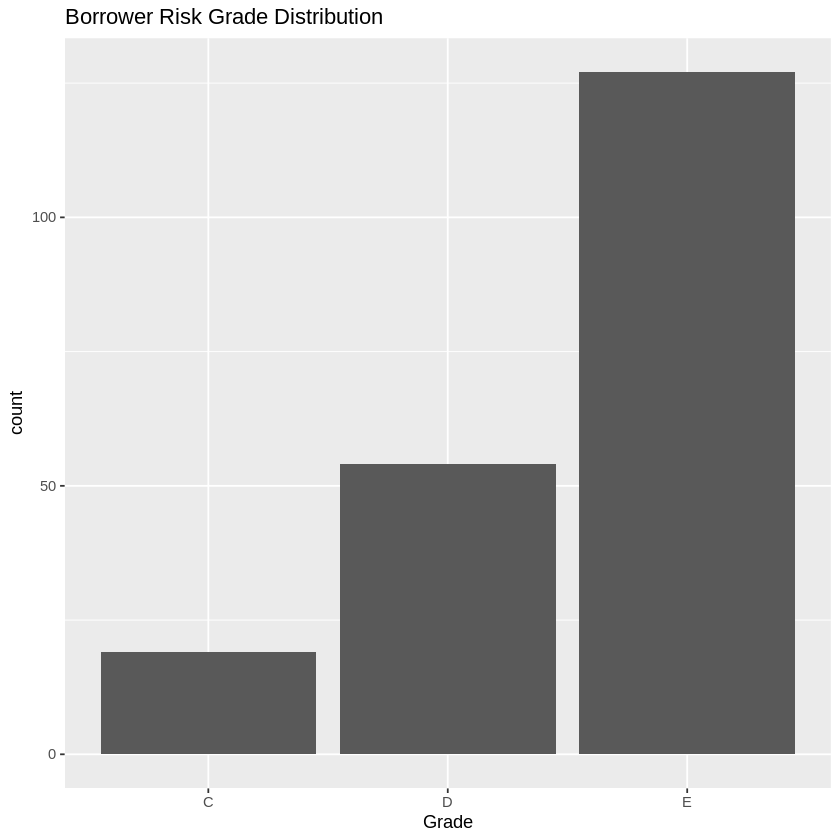

In [ ]:
ggplot(
  results,
  aes(x = Grade)
) +
  geom_bar() +
  ggtitle("Borrower Risk Grade Distribution")

# **Step 21: Identifying the Highest-Risk Borrowers**

The final stage of the project focuses on borrower-level risk prioritization.

Rather than examining the entire portfolio, attention shifts toward the subset of applicants most likely to generate future credit losses.

In practice, this is where risk models deliver the greatest business value.

Credit analysts, underwriting teams, and portfolio managers are often less concerned with the safest borrowers and more focused on identifying:

*   Potential future defaults.
*   High-loss exposures.
*   Deteriorating credit quality.
*   Applicants requiring enhanced due diligence.

**Initial Observation**

The first ranking exercise revealed another consequence of the probability-direction issue identified earlier.

The borrowers appearing at the top of the list were not the riskiest accounts.

In reality, they represented some of the strongest credit profiles in the portfolio.

**Characteristics of Strong Borrowers**

These applicants generally shared several common traits:

*   Short repayment durations.
*   Relatively modest credit exposure.
*   More mature age profiles.
*   Strong overall probability scores.

These findings align closely with the relationships identified earlier in the Logistic Regression model.

**Final Risk Monitoring Framework**

Once the probability direction is corrected, the ranking process becomes a powerful portfolio surveillance tool.

The institution can immediately identify:

*   Borrowers with elevated default probability.
*   Accounts requiring manual intervention.
*   Segments driving portfolio risk.
*   Candidates for rejection or tighter credit controls.

This transforms the model from a purely analytical exercise into a practical risk management framework capable of supporting real-world lending decisions.







In [ ]:
results %>%
  arrange(desc(PD)) %>%
  select(
    Age,
    Credit.amount,
    Duration,
    PD,
    Grade,
    Decision
  ) %>%
  head(20)

,Age,Credit.amount,Duration,PD,Grade,Decision
,<int>,<int>,<int>,<dbl>,<fct>,<chr>
1,61,3059,12,0.9838796,E,Reject
2,55,1413,12,0.9768735,E,Reject
3,41,250,6,0.9768656,E,Reject
4,38,1240,12,0.9755530,E,Reject
5,46,1582,18,0.9743730,E,Reject
6,46,730,7,0.9736452,E,Reject
7,59,5045,15,0.9730776,E,Reject
8,33,1543,6,0.9724265,E,Reject
9,27,1221,6,0.9696624,E,Reject
